In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/diabetes.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nOutcome distribution:\n", df['Outcome'].value_counts())

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


## great no missing values lol

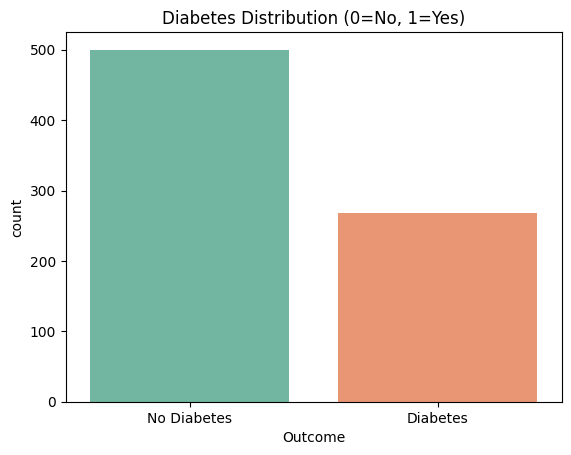

In [8]:
# class distribution
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Diabetes Distribution (0=No, 1=Yes)')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

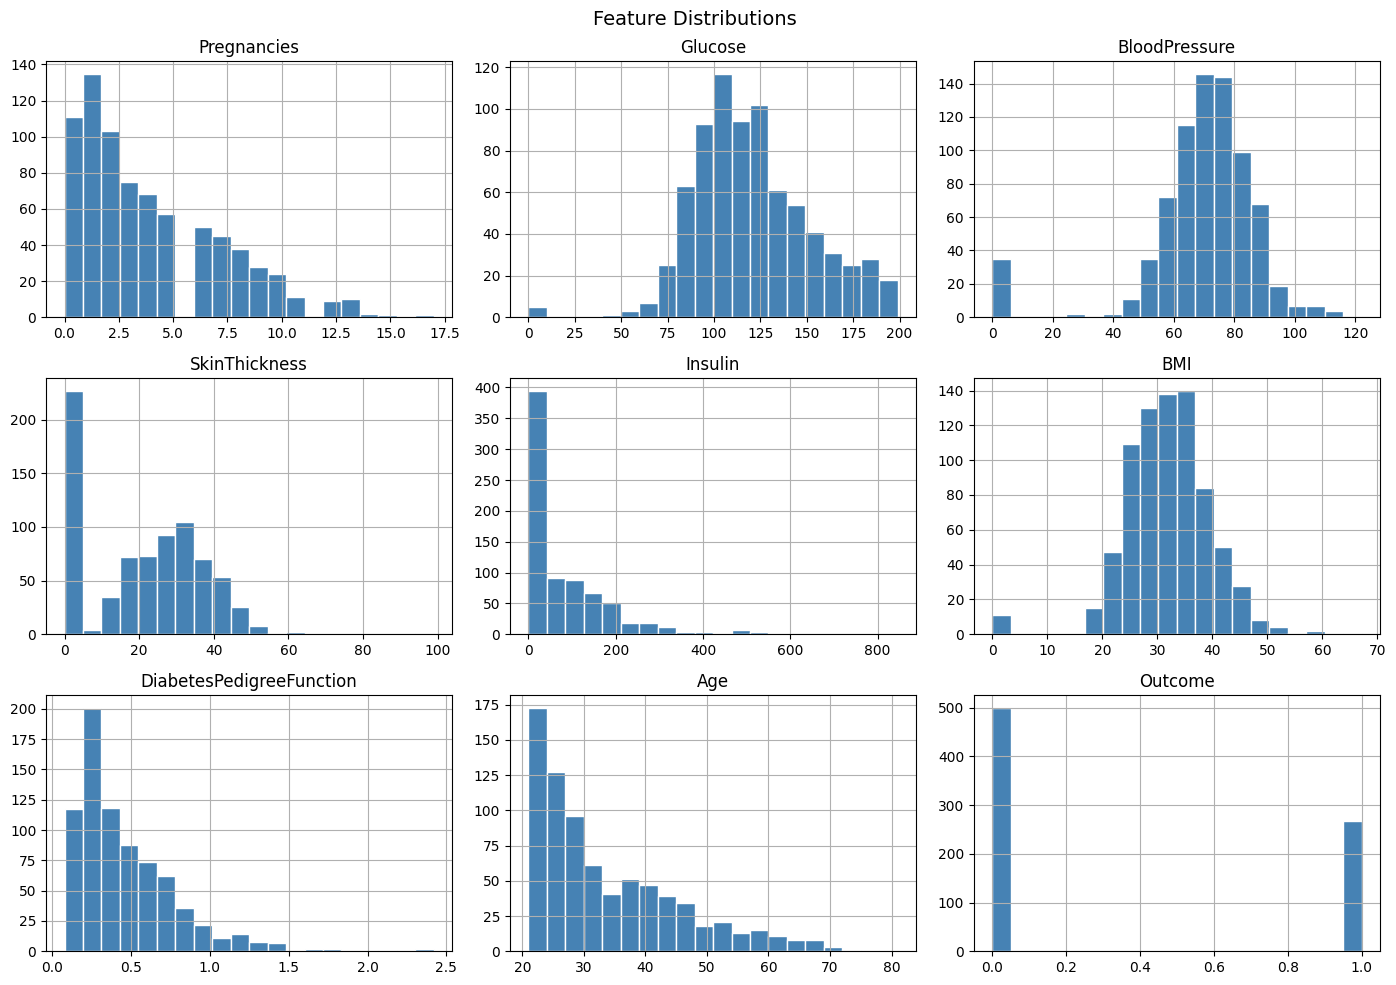

In [9]:
df.hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

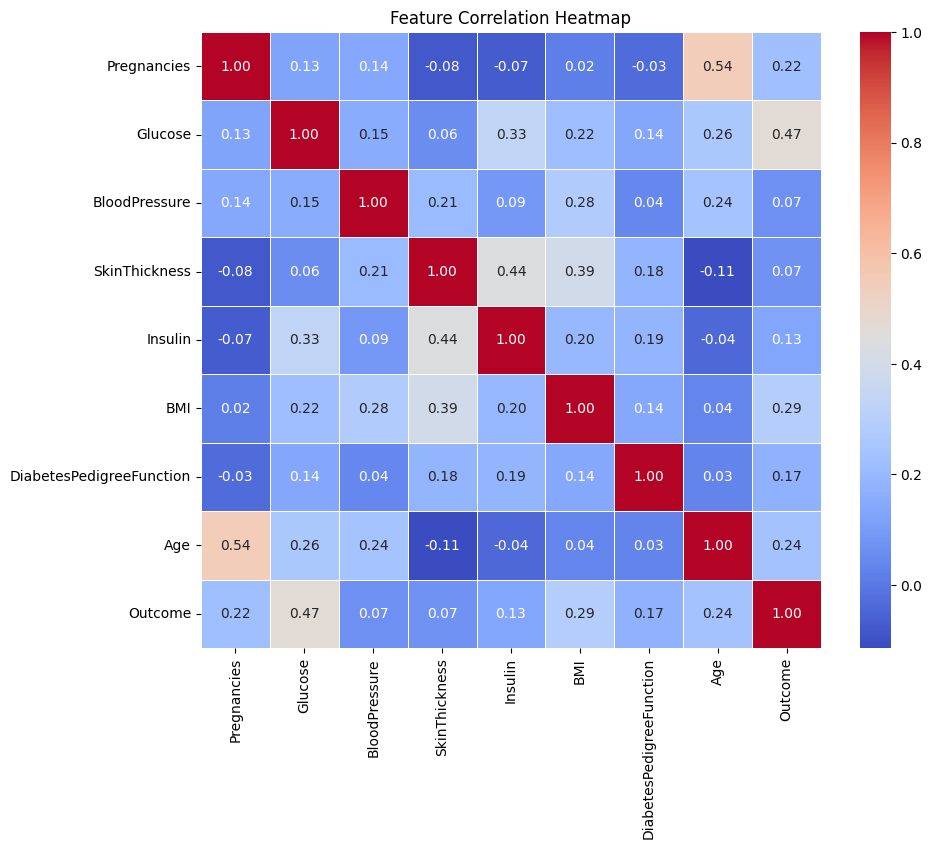

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### glucose being the most imp attribute

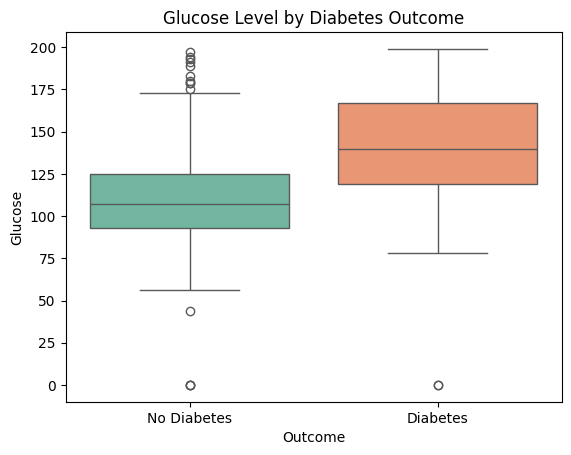

In [11]:
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2')
plt.title('Glucose Level by Diabetes Outcome')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

In [13]:
# In this dataset, 0s in these columns are biologically impossible = missing values
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)
    print(f"{col}: replaced 0s with median ({median_val:.1f})")

print("\nData cleaned")

Glucose: replaced 0s with median (117.0)
BloodPressure: replaced 0s with median (72.0)
SkinThickness: replaced 0s with median (23.0)
Insulin: replaced 0s with median (31.2)
BMI: replaced 0s with median (32.0)

Data cleaned


In [14]:
X = df.drop('Outcome', axis=1)   # all columns except target
y = df['Outcome']                 # target column

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (768, 8)
Target shape: (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
